#23CO315 - Piyusha Supe
**NLP - Practical 4**

Create a transformer from scratch using the Pytorch library

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

In [28]:
def attention(query, key, value):
    d_k = query.size(-1)

    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    attn = torch.softmax(scores, dim=-1)

    output = torch.matmul(attn, value)

    return output, attn

In [29]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.q = nn.Linear(d_model, d_model)
        self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model)

        self.fc = nn.Linear(d_model, d_model)

    def forward(self, x):
        batch_size = x.size(0)

        q = self.q(x)
        k = self.k(x)
        v = self.v(x)

        q = q.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        k = k.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)
        v = v.view(batch_size, -1, self.num_heads, self.d_k).transpose(1, 2)

        output, attn = attention(q, k, v)

        output = output.transpose(1,2).contiguous().view(batch_size, -1, self.num_heads * self.d_k)

        return self.fc(output), attn

In [30]:
class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 256)
        self.fc2 = nn.Linear(256, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

In [31]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads):
        super().__init__()

        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ff = FeedForward(d_model)

        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, attn = self.mha(x)
        x = self.norm1(x + attn_out)

        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        return x, attn

In [32]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=100):
        super().__init__()

        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)

        div_term = torch.exp(torch.arange(0, d_model, 2) * (-math.log(10000.0)/d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.pe = pe.unsqueeze(0)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [33]:
class Transformer(nn.Module):
    def __init__(self, vocab_size, d_model=64, num_heads=4):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, d_model)
        self.pos = PositionalEncoding(d_model)

        self.encoder = EncoderLayer(d_model, num_heads)

        self.fc = nn.Linear(d_model, vocab_size)

    def forward(self, src):
        x = self.embedding(src)
        x = self.pos(x)

        x, attn = self.encoder(x)

        out = self.fc(x)

        return out, attn

In [34]:
model = Transformer(vocab_size=1000)

src = torch.randint(0, 1000, (1, 10))

output, attn = model(src)

print("Output shape:", output.shape)
print("Attention shape:", attn.shape)

Output shape: torch.Size([1, 10, 1000])
Attention shape: torch.Size([1, 4, 10, 10])


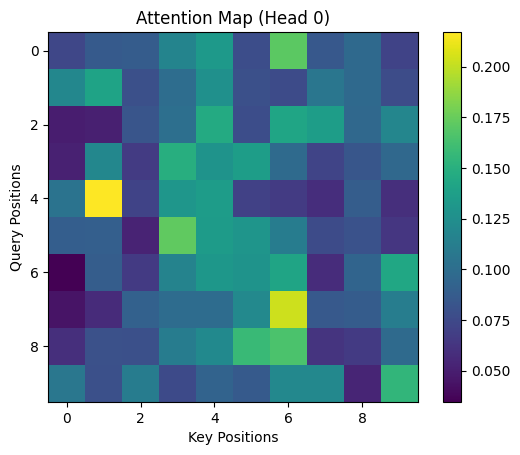

In [36]:
attn_map = attn[0][0].detach().numpy()

plt.figure()
plt.imshow(attn_map)
plt.title("Attention Map (Head 0)")
plt.xlabel("Key Positions")
plt.ylabel("Query Positions")
plt.colorbar()
plt.show()

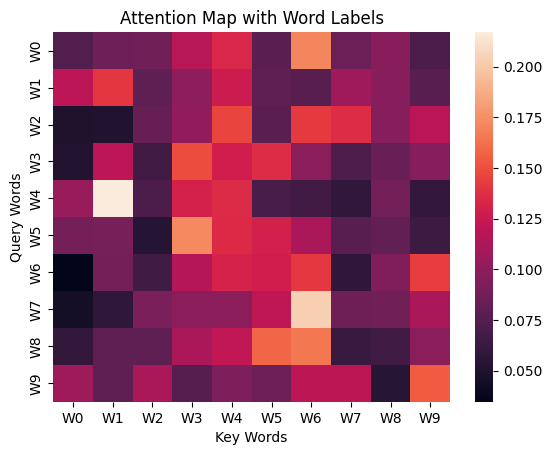

In [38]:
# Dummy words (replace with real tokens if available)
words = [f"W{i}" for i in range(attn_map.shape[0])]

import seaborn as sns

plt.figure()
sns.heatmap(attn_map, xticklabels=words, yticklabels=words)
plt.title("Attention Map with Word Labels")
plt.xlabel("Key Words")
plt.ylabel("Query Words")
plt.show()

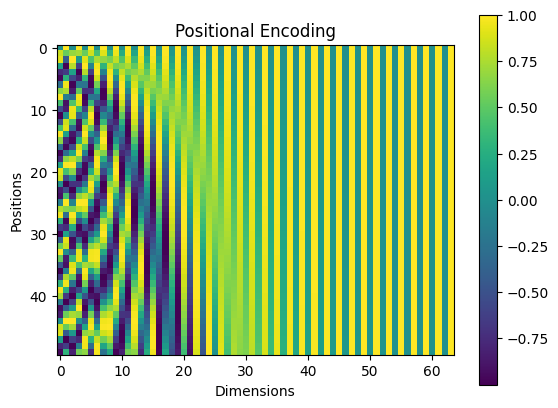

In [39]:
pe = model.pos.pe[0].detach().numpy()

plt.figure()
plt.imshow(pe[:50])
plt.title("Positional Encoding")
plt.xlabel("Dimensions")
plt.ylabel("Positions")
plt.colorbar()
plt.show()

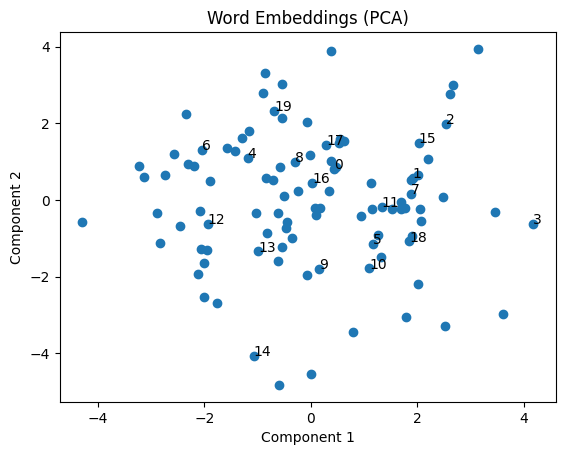

In [40]:
from sklearn.decomposition import PCA

embeddings = model.embedding.weight.detach().numpy()

pca = PCA(n_components=2)
result = pca.fit_transform(embeddings[:100])

plt.figure()
plt.scatter(result[:, 0], result[:, 1])

for i in range(20):
    plt.annotate(str(i), (result[i, 0], result[i, 1]))

plt.title("Word Embeddings (PCA)")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()

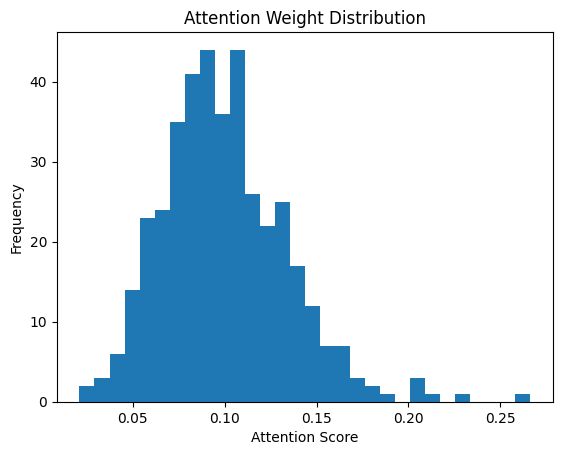

In [41]:
attention_values = attn.detach().numpy().flatten()

plt.figure()
plt.hist(attention_values, bins=30)
plt.title("Attention Weight Distribution")
plt.xlabel("Attention Score")
plt.ylabel("Frequency")
plt.show()

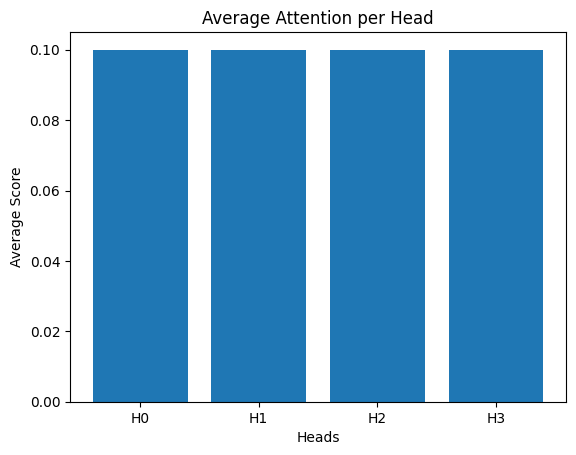

In [42]:
avg_attention = attn.mean(dim=(0,2,3)).detach().numpy()

heads = [f"H{i}" for i in range(len(avg_attention))]

plt.figure()
plt.bar(heads, avg_attention)
plt.title("Average Attention per Head")
plt.xlabel("Heads")
plt.ylabel("Average Score")
plt.show()